# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

../xvfb: line 3: $'\r': command not found
../xvfb: line 6: $'\r': command not found
../xvfb: line 21: syntax error near unexpected token `$'in\r''
../xvfb: line 21: `case "$1" in
'


In [2]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

C:\Users\wizze\anaconda3\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


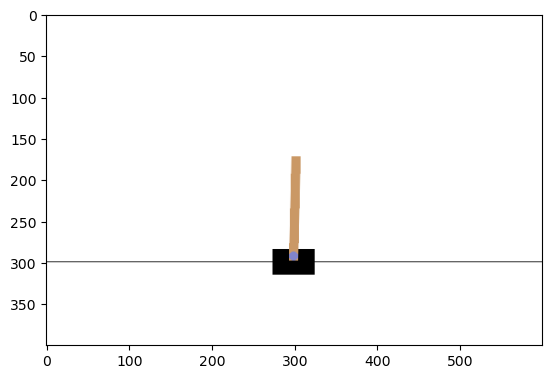

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [4]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

,hidden_layer_sizes,"(20, ...)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,None


In [5]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [6]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.02155198 -0.02015744 -0.00800986  0.0107842 ]
 [ 0.02114883 -0.2151636  -0.00779418  0.3009292 ]
 [ 0.01684556 -0.4101736  -0.0017756   0.59114385]
 [ 0.00864209 -0.21502684  0.01004728  0.29790214]
 [ 0.00434155 -0.02004954  0.01600532  0.0084048 ]]
actions: [0, 0, 1, 1, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [7]:
# def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
#     """
#     Select states and actions from games that have rewards >= percentile
#     :param states_batch: list of lists of states, states_batch[session_i][t]
#     :param actions_batch: list of lists of actions, actions_batch[session_i][t]
#     :param rewards_batch: list of rewards, rewards_batch[session_i]

#     :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

#     Please return elite states and actions in their original order
#     [i.e. sorted by session number and timestep within session]

#     If you are confused, see examples below. Please don't assume that states are integers
#     (they will become different later).
#     """

#     <YOUR CODE: copy-paste your implementation from the previous notebook>

#     return elite_states, elite_actions

def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """
    # 1. Вычисляем порог награды
    reward_threshold = np.percentile(rewards_batch, percentile)
    # 2. Отбираем состояния и действия из сессий с наградой >= порога
    elite_states = []
    elite_actions = []

    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [8]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 975.360, threshold=1000.000


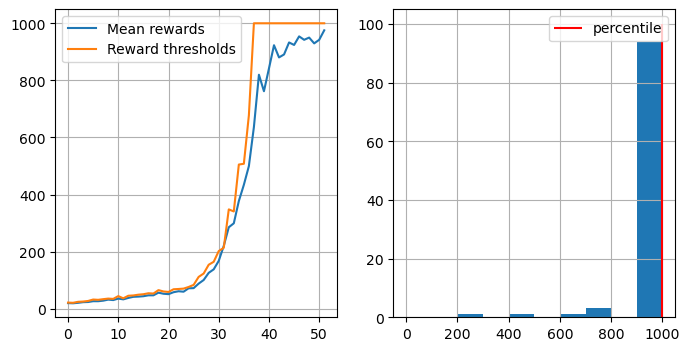

You Win! You may stop training now via KeyboardInterrupt.


KeyboardInterrupt: 

In [9]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    sessions = [generate_session(env, agent, t_max=1000) for _ in range(n_sessions)]
    
    # ИСПРАВЛЕНИЕ — убери map(np.array, ...):
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    
    agent.partial_fit(elite_states, elite_actions)
    
    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )
    
    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")

# Results

In [10]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


C:\Users\wizze\anaconda3\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
C:\Users\wizze\anaconda3\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at C:\Users\wizze\RL_Labs_Annenko_FI2\week01_intro\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [11]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


---

## ВАЖНО: РЕШЕНИЕ Homework part I

### **1.1** и **1.2** -> смотрите в файле: 
### [crossentropy_method.ipynb](./crossentropy_method.ipynb)
#### *(в конце блокнота)*

---

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

In [ ]:
def visualize_mountain_car(env, agent):
    # Compute policy for all possible x and v (with discretization)
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # # The above code is equivalent to the following:
    # probs = np.empty((len(vs), len(xs), 3))
    # for i, v in enumerate(vs[::-1]):
    #     for j, x in enumerate(xs):
    #         probs[i, j, :] = agent.predict_proba([[x, v]])[0]

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)


with gym.make("MountainCar-v0", render_mode="rgb_arrary").env as env:
    visualize_mountain_car(env, agent)


# Реализация для Homework part II

Размерность наблюдения: 2
Количество действий: 3
Начальное состояние: [-0.46352962  0.        ]
Диапазон позиции: [-1.2, 0.6]


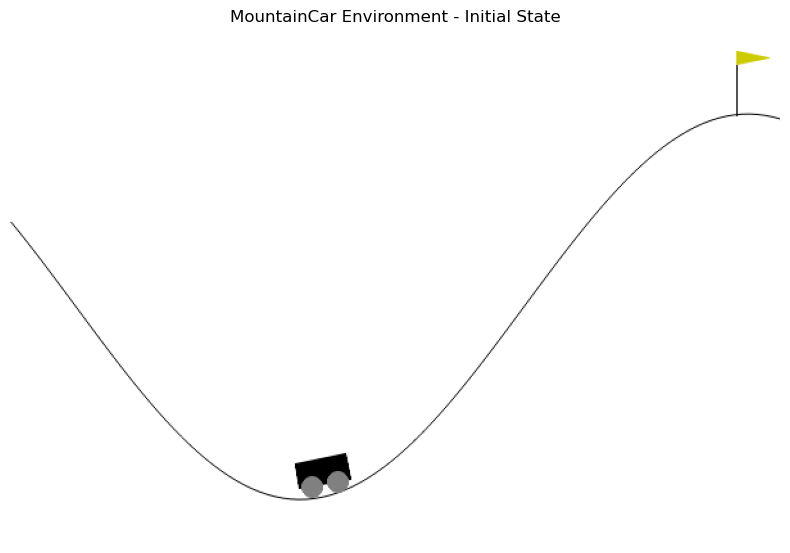

In [12]:
# Импортируем необходимые библиотеки
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Создаём среду MountainCar
mountain_car_env = gym.make("MountainCar-v0", render_mode="rgb_array").env

# Сбрасываем среду с заданным seed
initial_state, _ = mountain_car_env.reset(seed=123)

# Получаем информацию о среде
num_actions = mountain_car_env.action_space.n
observation_dim = mountain_car_env.observation_space.shape[0]

# Выводим информацию
print(f"Размерность наблюдения: {observation_dim}")
print(f"Количество действий: {num_actions}")
print(f"Начальное состояние: {initial_state}")
print(f"Диапазон позиции: [{mountain_car_env.unwrapped.min_position}, {mountain_car_env.unwrapped.max_position}]")

# Показываем среду
plt.figure(figsize=(8, 6))
plt.imshow(mountain_car_env.render())
plt.title("MountainCar Environment - Initial State")
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Получаем границы пространства наблюдений
observation_min = mountain_car_env.observation_space.low
observation_max = mountain_car_env.observation_space.high

def normalize_states(states_array):
    """
    Нормализует состояния в диапазон [-1, 1]
    """
    states_array = np.asarray(states_array)
    # Нормализация: (x - min) / (max - min) * 2 - 1
    normalized = 2 * (states_array - observation_min) / (observation_max - observation_min) - 1
    return normalized

In [14]:
# Импортируем нейросеть из sklearn
from sklearn.neural_network import MLPClassifier

# Создаём нейросеть с следующими параметрами
policy_network = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="tanh",
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=1,
    warm_start=True,
    random_state=123,
    early_stopping=False
)

# Сбрасываем среду для инициализации
initial_obs, _ = mountain_car_env.reset(seed=123)

# Инициализируем нейросеть (фиктивные данные)
policy_network.partial_fit(
    normalize_states(np.repeat(initial_obs[None, :], num_actions, axis=0)),
    np.arange(num_actions),
    classes=np.arange(num_actions)
)

,hidden_layer_sizes,"(128, ...)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1
,shuffle,True
,random_state,123


In [15]:
def play_episode(environment, agent, max_steps=15000, exploration_rate=0.03, use_greedy=False):
    """
    Play one episode (game) and return trajectory.
    
    Args:
        environment: Gym environment
        agent: Neural network agent
        max_steps: Maximum number of steps
        exploration_rate: Epsilon for epsilon-greedy
        use_greedy: If True, always choose best action
    
    Returns:
        states: list of states
        actions: list of actions
        total_reward: sum of rewards
    """
    trajectory_states = []
    trajectory_actions = []
    episode_reward = 0
    
    # Сбрасываем среду
    current_state, _ = environment.reset()
    
    for step in range(max_steps):
        # Предсказываем вероятности действий
        state_normalized = normalize_states([current_state])
        action_probs = agent.predict_proba(state_normalized)[0]
        
        # Нормализуем вероятности (на случай числовых ошибок)
        action_probs = action_probs / np.sum(action_probs)
        
        # Выбор действия
        if use_greedy:
            # Жадная стратегия - всегда лучшее действие
            chosen_action = int(np.argmax(action_probs))
        else:
            # Epsilon-greedy стратегия
            # С вероятностью (1-epsilon) выбираем лучшее действие
            # С вероятностью epsilon выбираем случайное действие
            action_probs = (1 - exploration_rate) * action_probs + exploration_rate / num_actions
            action_probs = action_probs / np.sum(action_probs)
            chosen_action = np.random.choice(num_actions, p=action_probs)
        
        # Делаем шаг в среде
        next_state, reward, terminated, truncated, _ = environment.step(chosen_action)
        
        # Записываем в траекторию
        trajectory_states.append(current_state)
        trajectory_actions.append(chosen_action)
        episode_reward += reward
        
        # Переходим к следующему состоянию
        current_state = next_state
        
        # Проверяем конец эпизода
        if terminated or truncated:
            break
    
    return trajectory_states, trajectory_actions, episode_reward

In [16]:
def filter_elite_trajectories(
    states_collection, 
    actions_collection, 
    rewards_collection, 
    elite_percentile=75
):
    """
    Select elite trajectories based on reward percentile.
    
    Args:
        states_collection: List of lists of states
        actions_collection: List of lists of actions  
        rewards_collection: List of total rewards
        elite_percentile: Percentile threshold for elite selection
    
    Returns:
        elite_states: Flattened array of elite states
        elite_actions: Flattened array of elite actions
    """
    # Преобразуем награды в numpy массив
    rewards_array = np.asarray(rewards_collection)
    
    # Вычисляем порог для элитных сессий
    threshold_value = np.percentile(rewards_array, elite_percentile)
    
    # Списки для элитных данных
    selected_states = []
    selected_actions = []
    
    # Отбираем сессии, которые лучше порога
    for state_seq, action_seq, total_reward in zip(
        states_collection, 
        actions_collection, 
        rewards_collection
    ):
        if total_reward > threshold_value:  # Строгое неравенство
            selected_states.extend(state_seq)
            selected_actions.extend(action_seq)
    
    # Обработка случая, когда ни одна сессия не прошла отбор
    if len(selected_states) == 0:
        print(f"Warning: No sessions above threshold {threshold_value:.2f}")
        print(f"Taking the best session (reward = {np.max(rewards_array):.2f})")
        
        # Находим лучшую сессию
        max_reward = np.max(rewards_array)
        for state_seq, action_seq, total_reward in zip(
            states_collection, 
            actions_collection, 
            rewards_collection
        ):
            if total_reward == max_reward:
                selected_states.extend(state_seq)
                selected_actions.extend(action_seq)
                break
    
    # Возвращаем как numpy массивы
    return np.asarray(selected_states), np.asarray(selected_actions)

In [17]:
def evaluate_final_agent(environment, policy_agent, num_test_episodes=50, max_steps=15000):
    """
    Evaluate trained agent performance over multiple greedy episodes.
    
    Args:
        environment: Gym environment
        policy_agent: Trained neural network
        num_test_episodes: Number of test games
        max_steps: Maximum steps per episode
        
    Returns:
        tuple: (mean_reward, std_reward)
    """
    test_rewards = []
    
    for _ in range(num_test_episodes):
        # Запускаем игру без исследования (жадная политика)
        _, _, episode_reward = play_episode(
            environment,
            policy_agent,
            max_steps=max_steps,
            exploration_rate=0.0,  # Отключаем случайность
            use_greedy=True        # Всегда выбираем лучшее действие
        )
        test_rewards.append(episode_reward)
    
    # Считаем статистику
    average_reward = np.mean(test_rewards)
    reward_std = np.std(test_rewards)
    
    return average_reward, reward_std

In [18]:
from collections import deque
from IPython.display import clear_output
import matplotlib.pyplot as plt

def train_mountain_car_agent(
    environment,
    policy_net,
    episodes_per_iter=100,
    elite_cutoff=75,
    max_epochs=120,
    memory_horizon=3,
    step_limit=15000,
    exploration=0.03,
    max_elite_samples=40000,
    goal_reward=-150
):
    """
    Train agent using Deep Crossentropy Method with replay memory.
    """
    training_history = []
    session_memory = deque(maxlen=memory_horizon)

    for epoch in range(max_epochs):
        # 1. Генерируем новые эпизоды
        new_episodes = [
            play_episode(environment, policy_net, step_limit, exploration, use_greedy=False)
            for _ in range(episodes_per_iter)
        ]

        # 2. Добавляем в память и объединяем
        session_memory.append(new_episodes)
        all_episodes = [ep for batch in session_memory for ep in batch]

        # 3. Распаковываем данные
        states_col, actions_col, rewards_col = zip(*all_episodes)

        # 4. Отбираем элитные траектории
        elite_s, elite_a = filter_elite_trajectories(
            states_col,
            actions_col,
            rewards_col,
            elite_percentile=elite_cutoff
        )

        # 5. Сэмплируем, если элит слишком много (ускоряет обучение)
        if len(elite_s) > max_elite_samples:
            indices = np.random.choice(len(elite_s), size=max_elite_samples, replace=False)
            elite_s = elite_s[indices]
            elite_a = elite_a[indices]

        # 6. Обновляем нейросеть
        policy_net.partial_fit(
            normalize_states(elite_s),
            elite_a,
            classes=np.arange(num_actions)
        )

        # 7. Оцениваем текущую производительность
        current_rewards = np.asarray([ep[2] for ep in new_episodes])
        eval_avg, eval_std = evaluate_final_agent(
            environment, policy_net, num_test_episodes=30, max_steps=step_limit
        )

        # 8. Сохраняем метрики
        training_history.append({
            "epoch": epoch,
            "train_mean": np.mean(current_rewards),
            "threshold": np.percentile(rewards_col, elite_cutoff),
            "eval_mean": eval_avg,
            "eval_std": eval_std
        })

        # 9. Показываем прогресс
        clear_output(True)
        print(f"Epoch: {epoch}/{max_epochs}")
        print(f"Train Reward: {np.mean(current_rewards):.2f}")
        print(f"Elite Threshold: {training_history[-1]['threshold']:.2f}")
        print(f"Greedy Eval: {eval_avg:.2f} ± {eval_std:.2f}")

        plt.figure(figsize=(10, 5))
        plt.plot([h["train_mean"] for h in training_history], label="Train Mean")
        plt.plot([h["threshold"] for h in training_history], label="Elite Threshold")
        plt.plot([h["eval_mean"] for h in training_history], label="Greedy Eval")
        plt.axhline(goal_reward, color="red", linestyle="--", label=f"Target ({goal_reward})")
        plt.xlabel("Epoch")
        plt.ylabel("Reward")
        plt.title("MountainCar Deep CEM Training")
        plt.legend()
        plt.grid(True)
        plt.show()

        # 10. Остановка при достижении цели
        if eval_avg >= goal_reward:
            print(f"\n Success! Target score {goal_reward} reached at epoch {epoch}.")
            break

    return policy_net, training_history

Epoch: 4/50
Train Reward: -4818.20
Elite Threshold: -5000.00
Greedy Eval: -117.17 ± 9.82


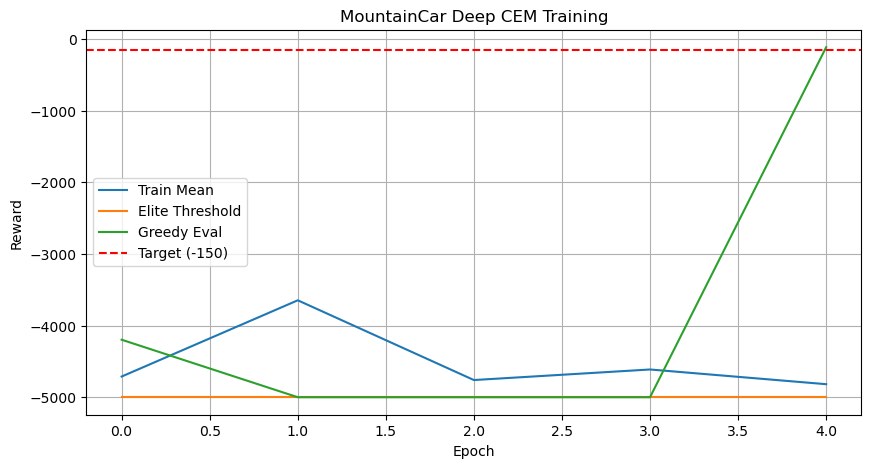


 Success! Target score -150 reached at epoch 4.


In [19]:
trained_policy, training_log = train_mountain_car_agent(
    environment=mountain_car_env,
    policy_net=policy_network,
    episodes_per_iter=30,
    elite_cutoff=50,
    max_epochs=50,
    memory_horizon=3,
    step_limit=5000,
    exploration=0.1,
    max_elite_samples=20000,
    goal_reward=-150
)

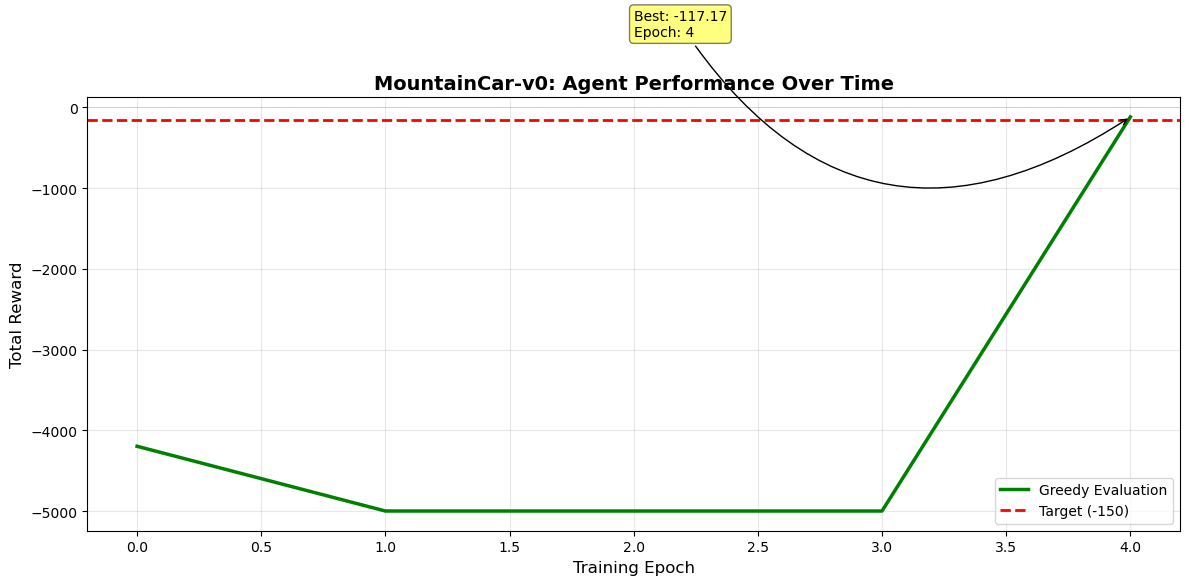

 TRAINING SUMMARY
Total epochs: 5
Final greedy reward: -117.17
Best greedy reward: -117.17 (epoch 4)
Target achieved:  YES


In [21]:
goal_reward = -150

# Визуализация результатов обучения
plt.figure(figsize=(12, 6))

# Извлекаем данные о жадной оценке из лога
greedy_rewards = [entry["eval_mean"] for entry in training_log]

# Строим график
plt.plot(greedy_rewards, linewidth=2.5, label="Greedy Evaluation", color="green")

# Добавляем целевую линию
plt.axhline(y=goal_reward, color="red", linestyle="--", linewidth=2, label=f"Target ({goal_reward})")

# Добавляем горизонтальную линию на нуле (идеальный результат)
plt.axhline(y=0, color="gray", linestyle="-", linewidth=0.5, alpha=0.3)

# Подписи и заголовок
plt.xlabel("Training Epoch", fontsize=12)
plt.ylabel("Total Reward", fontsize=12)
plt.title("MountainCar-v0: Agent Performance Over Time", fontsize=14, fontweight="bold")

# Легенда и сетка
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)

# Добавляем аннотацию с лучшим результатом
best_epoch = np.argmax(greedy_rewards)
best_reward = greedy_rewards[best_epoch]

# Позиция аннотации (адаптивная)
if best_epoch < 3:
    # Если лучшая эпоха в начале — ставим текст справа
    xytext=(best_epoch + 2, best_reward - 1000)
else:
    # Иначе ставим текст слева сверху
    xytext=(best_epoch - 2, best_reward + 1000)

plt.annotate(
    f"Best: {best_reward:.2f}\nEpoch: {best_epoch}",
    xy=(best_epoch, best_reward),
    xytext=xytext,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.5", color="black")
)

plt.tight_layout()
plt.show()

# Выводим финальную статистику
print("=" * 60)
print(" TRAINING SUMMARY")
print("=" * 60)
print(f"Total epochs: {len(training_log)}")
print(f"Final greedy reward: {greedy_rewards[-1]:.2f}")
print(f"Best greedy reward: {best_reward:.2f} (epoch {best_epoch})")
print(f"Target achieved: {' YES' if best_reward >= goal_reward else ' NO'}")
print("=" * 60)

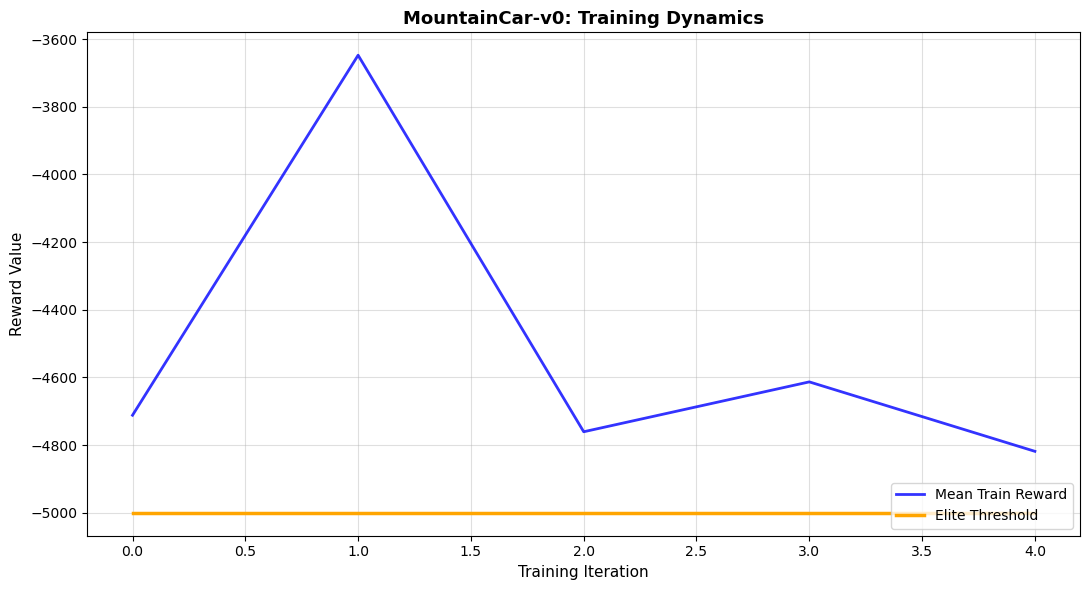

 TRAINING DYNAMICS ANALYSIS
Initial train reward: -4711.57
Final train reward: -4818.20
Improvement: -106.63
Final threshold: -5000.00


In [22]:
# Визуализация процесса обучения
plt.figure(figsize=(11, 6))

# Извлекаем данные из лога
train_rewards = [entry["train_mean"] for entry in training_log]
thresholds = [entry["threshold"] for entry in training_log]
iterations = range(len(training_log))

# Строим графики
plt.plot(iterations, train_rewards, linewidth=2, label="Mean Train Reward", color="blue", alpha=0.8)
plt.plot(iterations, thresholds, linewidth=2.5, label="Elite Threshold", color="orange")

# Добавляем подписи и заголовок
plt.xlabel("Training Iteration", fontsize=11)
plt.ylabel("Reward Value", fontsize=11)
plt.title("MountainCar-v0: Training Dynamics", fontsize=13, fontweight="bold")

# Легенда и сетка
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.4)

# Добавляем вертикальную линию где агент начал учиться
if len(train_rewards) > 10:
    improvement_point = np.argmax(np.array(train_rewards) > -4000)
    if improvement_point > 0:
        plt.axvline(x=improvement_point, color="green", linestyle=":", alpha=0.5, 
                   label=f"Learning started (iter {improvement_point})")

plt.tight_layout()
plt.show()

# Выводим статистику
print("=" * 60)
print(" TRAINING DYNAMICS ANALYSIS")
print("=" * 60)
print(f"Initial train reward: {train_rewards[0]:.2f}")
print(f"Final train reward: {train_rewards[-1]:.2f}")
print(f"Improvement: {train_rewards[-1] - train_rewards[0]:.2f}")
print(f"Final threshold: {thresholds[-1]:.2f}")
print("=" * 60)

In [23]:
print("=== ПРОВЕРКА СТАБИЛЬНОСТИ ===")
rewards = []
for i in range(10):
    _, _, reward = play_episode(
        mountain_car_env,
        trained_policy,
        max_steps=10000,
        exploration_rate=0.0,  # Ноль случайности!
        use_greedy=True
    )
    rewards.append(reward)
    print(f"Игра {i+1}: {reward:.2f}")

print(f"\nСреднее: {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
print(f"Мин: {min(rewards):.2f}, Макс: {max(rewards):.2f}")

=== ПРОВЕРКА СТАБИЛЬНОСТИ ===
Игра 1: -125.00
Игра 2: -125.00
Игра 3: -126.00
Игра 4: -123.00
Игра 5: -125.00
Игра 6: -126.00
Игра 7: -124.00
Игра 8: -118.00
Игра 9: -123.00
Игра 10: -119.00

Среднее: -123.40 ± 2.65
Мин: -126.00, Макс: -118.00


In [24]:
from sklearn.neural_network import MLPClassifier
import numpy as np

def create_enhanced_agent(seed=42):
    """
    Create improved neural network for better performance.
    """
    enhanced_agent = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="tanh",
        solver="adam",
        learning_rate_init=0.0003,
        alpha=0.00005,
        max_iter=1,
        warm_start=True,
        random_state=seed,
        early_stopping=False
    )
    
    # Инициализация
    initial_state, _ = mountain_car_env.reset(seed=seed)
    
    enhanced_agent.partial_fit(
        normalize_states(np.repeat(initial_state[None, :], num_actions, axis=0)),
        np.arange(num_actions),
        classes=np.arange(num_actions)
    )
    
    return enhanced_agent

In [25]:
def filter_best_trajectories(
    states_collection,
    actions_collection,
    scores_collection,
    cutoff_percentile=60
):
    """
    Filter elite trajectories based on score percentile.
    Returns elite states, actions, and the threshold value.
    """
    scores_array = np.asarray(scores_collection)
    threshold_value = np.percentile(scores_array, cutoff_percentile)
    
    selected_states = []
    selected_actions = []
    
    # Отбираем лучшие траектории
    for state_seq, action_seq, total_score in zip(
        states_collection, 
        actions_collection, 
        scores_collection
    ):
        if total_score > threshold_value:
            selected_states.extend(state_seq)
            selected_actions.extend(action_seq)
    
    # Если ничего не отобралось — берем лучшую сессию
    if len(selected_states) == 0:
        print(f"  Warning: No trajectories above threshold {threshold_value:.2f}")
        print(f"  Taking best trajectory (score = {np.max(scores_array):.2f})")
        
        best_score = np.max(scores_array)
        for state_seq, action_seq, total_score in zip(
            states_collection, 
            actions_collection, 
            scores_collection
        ):
            if total_score == best_score:
                selected_states.extend(state_seq)
                selected_actions.extend(action_seq)
                break
    
    return np.asarray(selected_states), np.asarray(selected_actions), threshold_value

In [26]:
from joblib import Parallel, delayed
import copy
import time

def run_parallel_episode(agent, seed, max_steps, exploration_rate):
    """
    Helper function for joblib. 
    Runs a single episode in a separate process.
    """
    # Создаем среду внутри воркера (важно!)
    worker_env = gym.make("MountainCar-v0", render_mode="rgb_array").env
    
    state, _ = worker_env.reset(seed=seed)
    ep_states, ep_actions, ep_reward = [], [], 0
    
    for _ in range(max_steps):
        # Предсказание
        norm_state = normalize_states([state])
        probs = agent.predict_proba(norm_state)[0]
        probs = probs / np.sum(probs)
        
        # Выбор действия (Epsilon-greedy)
        if np.random.random() < exploration_rate:
            action = np.random.choice(num_actions)
        else:
            action = int(np.argmax(probs))
            
        next_state, reward, terminated, truncated, _ = worker_env.step(action)
        
        ep_states.append(state)
        ep_actions.append(action)
        ep_reward += reward
        state = next_state
        
        if terminated or truncated:
            break
            
    return ep_states, ep_actions, ep_reward

In [29]:
def run_advanced_cem_training(
    agent,
    episodes_per_iter=160,
    cutoff_percentile=60,
    max_epochs=200,
    memory_depth=4,
    step_limit=10000,
    start_explore=0.20,
    min_explore=0.02,
    explore_decay=0.97,
    fit_steps=3,
    max_elite_size=80000,
    goal_score=-100,
    workers=2
):
    history = []
    session_memory = deque(maxlen=memory_depth)
    
    # Сохраняем лучшую версию агента
    top_policy = copy.deepcopy(agent)
    best_score = -float("inf")
    
    start_time = time.time()
    print(f"Starting Advanced Training with {workers} workers...")

    for iteration in range(max_epochs):
        # 1. Рассчитываем текущий epsilon (затухание)
        current_epsilon = max(min_explore, start_explore * (explore_decay ** iteration))

        # 2. Генерируем сессии ПАРАЛЛЕЛЬНО
        # Используем run_parallel_episode вместо обычной генерации
        new_sessions = Parallel(n_jobs=workers)(
            delayed(run_parallel_episode)(
                agent,
                seed=iteration * episodes_per_iter + i,
                max_steps=step_limit,
                exploration_rate=current_epsilon
            )
            for i in range(episodes_per_iter)
        )

        session_memory.append(new_sessions)

        # 3. Собираем все сессии из памяти
        all_sessions = [session for batch in session_memory for session in batch]
        
        if not all_sessions:
            continue

        states_col, actions_col, rewards_col = zip(*all_sessions)
        rewards_array = np.asarray(rewards_col)

        # 4. Отбор элиты
        elite_s, elite_a, _ = filter_best_trajectories(
            states_col,
            actions_col,
            rewards_array,
            cutoff_percentile=cutoff_percentile
        )

        # 5. Ограничение размера выборки (для скорости)
        if len(elite_s) > max_elite_size:
            idx = np.random.choice(len(elite_s), size=max_elite_size, replace=False)
            elite_s = elite_s[idx]
            elite_a = elite_a[idx]

        # 6. Обучение (несколько шагов на одних данных)
        for _ in range(fit_steps):
            shuffle_idx = np.random.permutation(len(elite_s))
            agent.partial_fit(
                normalize_states(elite_s[shuffle_idx]),
                elite_a[shuffle_idx],
                classes=np.arange(num_actions)
            )

        # 7. Оценка (тоже параллельно, но без случайности)
        # Для оценки используем 30 игр
        eval_sessions = Parallel(n_jobs=workers)(
            delayed(run_parallel_episode)(
                agent,
                seed=10000 + i,
                max_steps=step_limit,
                exploration_rate=0.0  # Greedy
            )
            for i in range(30)
        )
        eval_rewards = [s[2] for s in eval_sessions]
        eval_mean = np.mean(eval_rewards)
        eval_std = np.std(eval_rewards)

        # 8. Обновляем лучшего агента
        if eval_mean > best_score:
            best_score = eval_mean
            top_policy = copy.deepcopy(agent)

        # 9. Логирование
        history.append({
            "iteration": iteration,
            "epsilon": current_epsilon,
            "mean_reward": np.mean(rewards_col),
            "eval_mean": eval_mean,
            "eval_std": eval_std,
            "best_score": best_score
        })

        # 10. Вывод прогресса
        clear_output(True)
        print(f"Epoch: {iteration}/{max_epochs}")
        print(f"Epsilon: {current_epsilon:.3f}")
        print(f"Train Reward: {np.mean(rewards_col):.2f}")
        print(f"Greedy Eval: {eval_mean:.2f} ± {eval_std:.2f}")
        print(f"Best Score So Far: {best_score:.2f}")
        print(f"Time: {time.time() - start_time:.1f}s")

        # График
        plt.figure(figsize=(10, 5))
        plt.plot([h["eval_mean"] for h in history], label="Current Eval")
        plt.plot([h["best_score"] for h in history], label="Best Score", linestyle="--")
        plt.axhline(goal_score, color="red", linestyle=":", label=f"Target ({goal_score})")
        plt.legend()
        plt.grid(True)
        plt.title("Advanced CEM Training")
        plt.xlabel("Iteration")
        plt.ylabel("Reward")
        plt.show()

        if best_score >= goal_score:
            print(f"\n SUCCESS! Target {goal_score} reached at epoch {iteration}!")
            break

    return agent, history, top_policy

Epoch: 67/100
Epsilon: 0.026
Train Reward: -525.60
Greedy Eval: -3420.63 ± 4652.32
Best Score So Far: -2761.13
Time: 617.1s


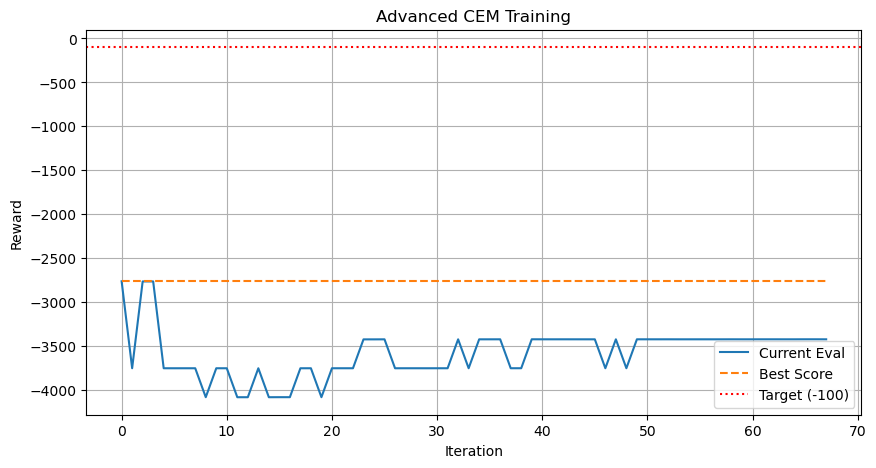

KeyboardInterrupt: 

In [30]:
final_agent, log, best_agent = run_advanced_cem_training(
    agent=policy_network,
    episodes_per_iter=100,
    max_epochs=100,
    workers=2,
    goal_score=-100
)

Epoch: 99/100
Epsilon: 0.010
Train Reward: -848.53
Greedy Eval: -2104.70 ± 3947.65
Best Score So Far: -2104.67
Time: 1343.2s


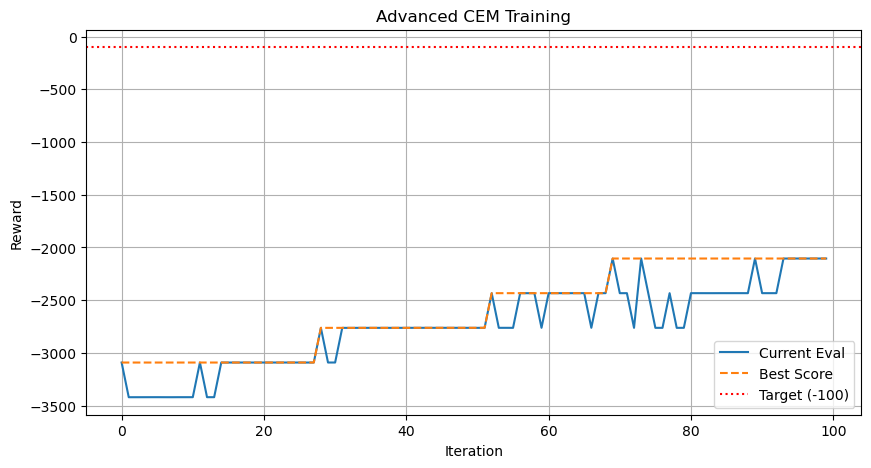

In [31]:
print("Fine-tuning для улучшения результата...")

finetuned_agent, finetuned_log, best_finetuned = run_advanced_cem_training(
    agent=trained_policy,  # Берём обученного агента
    episodes_per_iter=200,
    cutoff_percentile=80,
    max_epochs=100,
    memory_depth=5,
    step_limit=10000,
    start_explore=0.05,
    min_explore=0.01,
    explore_decay=0.98,
    fit_steps=5,
    max_elite_size=100000,
    goal_score=-100,
    workers=2
)

In [32]:
def normalize_states(states):
    """
    Улучшенная нормализация с дополнительными признаками.
    """
    states = np.asarray(states)
    
    if states.ndim == 1:
        states = states.reshape(1, -1)
    
    x = states[:, 0]  # позиция
    v = states[:, 1]  # скорость
    
    # Базовая нормализация
    x_norm = (x + 1.2) / 1.8
    v_norm = (v + 0.07) / 0.14
    
    # Добавляем 3 дополнительных признака:
    return np.column_stack([
        x_norm,
        v_norm,
        x_norm ** 2,      # квадрат позиции
        np.sign(v)        # направление скорости
    ])

Epoch: 20/100
Train Reward: -500.00
Elite Threshold: -500.00
Greedy Eval: -500.00 ± 0.00


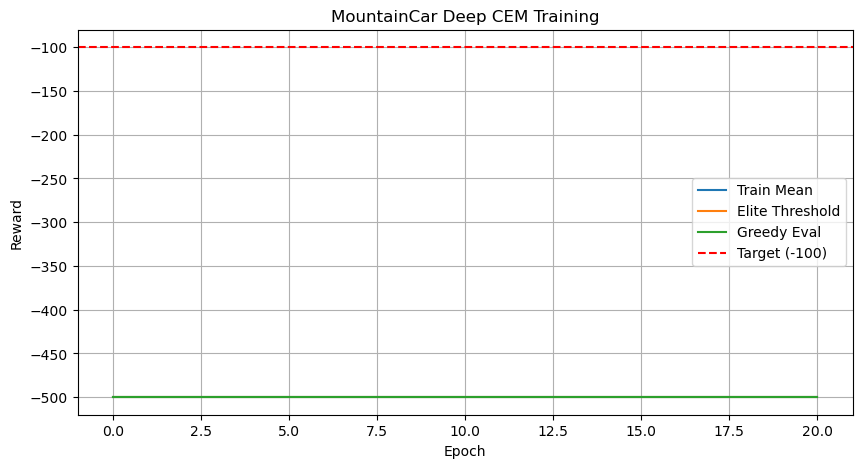

Taking the best session (reward = -500.00)


KeyboardInterrupt: 

In [34]:
# Создаём нового агента (с новой архитектурой под 4 признака)
from sklearn.neural_network import MLPClassifier

smart_agent = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="tanh",
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=1,
    warm_start=True,
    random_state=42,
    early_stopping=False
)

# Инициализация
initial_obs, _ = mountain_car_env.reset(seed=42)
smart_agent.partial_fit(
    normalize_states(np.repeat(initial_obs[None, :], num_actions, axis=0)),
    np.arange(num_actions),
    classes=np.arange(num_actions)
)

print("Агент создан! Теперь обучаем...")

# Обучаем
smart_agent, smart_log = train_mountain_car_agent(
    environment=mountain_car_env,
    policy_net=smart_agent,
    episodes_per_iter=100,
    elite_cutoff=75,
    max_epochs=100,
    memory_horizon=3,
    step_limit=500,
    exploration=0.1,
    max_elite_samples=40000,
    goal_reward=-100
)

In [35]:
def play_episode_with_bonus(env, agent, max_steps=1000, exploration_rate=0.1, use_greedy=False):
    """
    Играет один эпизод с бонусом за высоту.
    """
    current_state, _ = env.reset()
    episode_states, episode_actions, episode_reward = [], [], 0
    max_position = current_state[0]  # Запоминаем максимальную позицию
    
    for step in range(max_steps):
        # Предсказание действия
        state_normalized = normalize_states([current_state])
        action_probs = agent.predict_proba(state_normalized)[0]
        action_probs = action_probs / np.sum(action_probs)
        
        # Выбор действия
        if use_greedy or np.random.random() < exploration_rate:
            action = np.argmax(action_probs) if use_greedy else np.random.choice(num_actions)
        else:
            action = np.random.choice(num_actions, p=action_probs)
        
        # Шаг среды
        next_state, reward, terminated, truncated, _ = env.step(action)
        
        episode_states.append(current_state)
        episode_actions.append(action)
        episode_reward += reward
        max_position = max(max_position, next_state[0])  # Обновляем макс позицию
        
        current_state = next_state
        
        if terminated or truncated:
            break
    
    # Добавляем бонус за высоту!
    height_bonus = 100 * (max_position + 1.2)  # Чем выше, тем больше бонус
    modified_reward = episode_reward + height_bonus
    
    return episode_states, episode_actions, modified_reward

In [36]:
def train_agent_with_bonus(
    environment,
    policy_net,
    episodes_per_iter=100,
    elite_cutoff=70,
    max_epochs=100,
    memory_horizon=3,
    step_limit=2000,
    exploration=0.1,
    max_elite_samples=50000,
    goal_reward=-150
):
    from collections import deque
    import matplotlib.pyplot as plt
    
    log = []
    session_memory = deque(maxlen=memory_horizon)
    
    for epoch in range(max_epochs):
        # 1. Генерация сессий (ИСПОЛЬЗУЕМ play_episode_with_bonus!)
        sessions = []
        for _ in range(episodes_per_iter):
            states, actions, reward = play_episode_with_bonus(
                environment, policy_net, 
                max_steps=step_limit, 
                exploration_rate=exploration
            )
            sessions.append((states, actions, reward))
        
        session_memory.append(sessions)
        
        # 2. Сбор данных из памяти
        all_sessions = [session for batch in session_memory for session in batch]
        if not all_sessions:
            continue
            
        states_batch, actions_batch, rewards_batch = zip(*all_sessions)
        
        # 3. Отбор элиты (по модифицированной награде!)
        rewards_array = np.asarray(rewards_batch)
        threshold = np.percentile(rewards_array, elite_cutoff)
        
        elite_states, elite_actions = [], []
        for s, a, r in zip(states_batch, actions_batch, rewards_batch):
            if r >= threshold:
                elite_states.extend(s)
                elite_actions.extend(a)
        
        # Ограничение размера выборки
        if len(elite_states) > max_elite_samples:
            idx = np.random.choice(len(elite_states), size=max_elite_samples, replace=False)
            elite_states = np.asarray(elite_states)[idx]
            elite_actions = np.asarray(elite_actions)[idx]
            
        elite_states = np.asarray(elite_states)
        elite_actions = np.asarray(elite_actions)
        
        # 4. Обучение нейросети
        policy_net.partial_fit(
            normalize_states(elite_states),
            elite_actions,
            classes=np.arange(num_actions)
        )
        
        # 5. Оценка (Greedy Eval - без бонусов, честная игра)
        eval_rewards = []
        for _ in range(10):
            _, _, honest_reward = play_episode(
                environment, policy_net, 
                max_steps=step_limit, 
                exploration_rate=0.0, 
                use_greedy=True
            )
            eval_rewards.append(honest_reward)
            
        mean_train = np.mean(rewards_batch)
        mean_eval = np.mean(eval_rewards)
        
        log.append({"epoch": epoch, "train_mean": mean_train, "eval_mean": mean_eval})
        
        # Вывод и график
        if epoch % 5 == 0 or epoch == max_epochs - 1:
            print(f"Epoch: {epoch}/{max_epochs}")
            print(f"Train Reward (with bonus): {mean_train:.2f}")
            print(f"Honest Greedy Eval: {mean_eval:.2f}")
            
            plt.figure(figsize=(8, 5))
            plt.plot([x["eval_mean"] for x in log], label="Honest Greedy Eval", color="green")
            plt.axhline(goal_reward, color="red", linestyle="--", label=f"Target ({goal_reward})")
            plt.legend()
            plt.grid(True)
            plt.title("Training with Height Bonus")
            plt.show()
            
            if mean_eval >= goal_reward:
                print("Success! Target reached.")
                break
                
    return policy_net, log

Epoch: 0/100
Train Reward (with bonus): -1887.14
Honest Greedy Eval: -2000.00


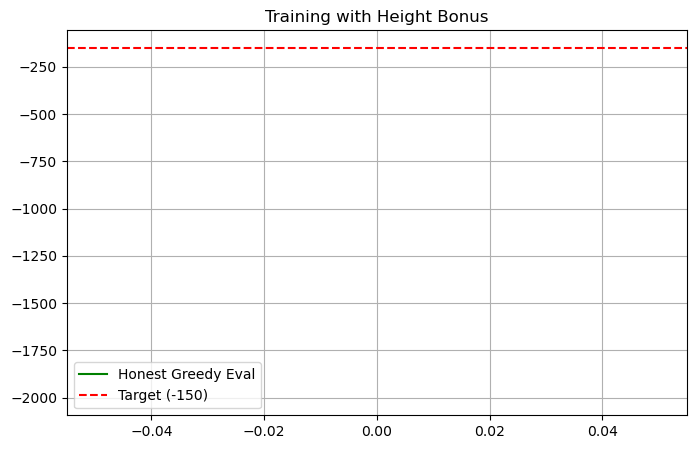

Epoch: 5/100
Train Reward (with bonus): -1367.92
Honest Greedy Eval: -2000.00


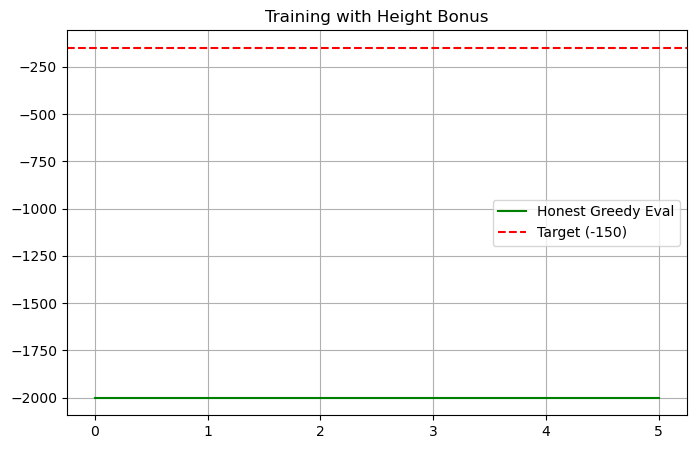

Epoch: 10/100
Train Reward (with bonus): -1027.91
Honest Greedy Eval: -119.10


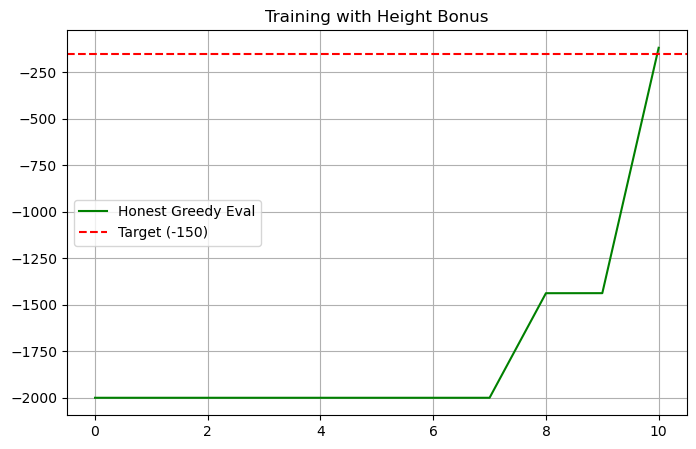

Success! Target reached.


In [37]:
# Запускаем обучение с бонусом!
bonus_agent, bonus_log = train_agent_with_bonus(
    environment=mountain_car_env,
    policy_net=smart_agent,  # Используем агента с 4 признаками
    episodes_per_iter=100,
    elite_cutoff=75,
    max_epochs=100,
    memory_horizon=3,
    step_limit=2000,         # Даем время разогнаться
    exploration=0.1,
    max_elite_samples=50000,
    goal_reward=-150         # Для начала цель -150
)

In [38]:
import copy

# Сохраняем текущего агента (-119) в "сейф"
agent_saved_v1 = copy.deepcopy(bonus_agent)
print("Агент сохранён! Теперь можно экспериментировать дальше.")

Агент сохранён! Теперь можно экспериментировать дальше.


Epoch: 0/100
Train Reward (with bonus): -578.55
Honest Greedy Eval: -117.30


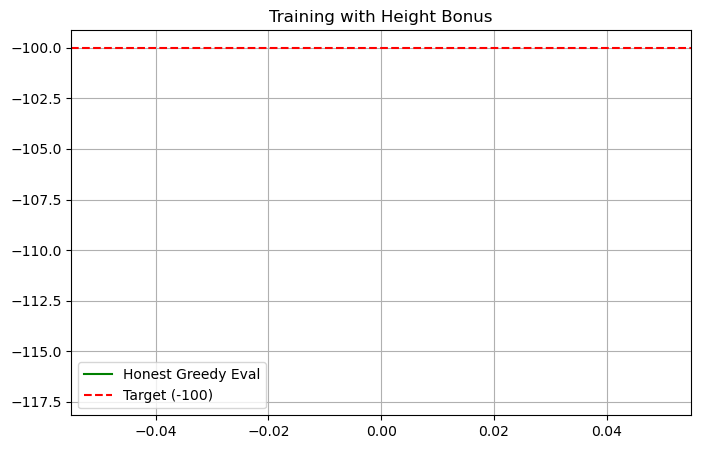

Epoch: 5/100
Train Reward (with bonus): -318.32
Honest Greedy Eval: -119.30


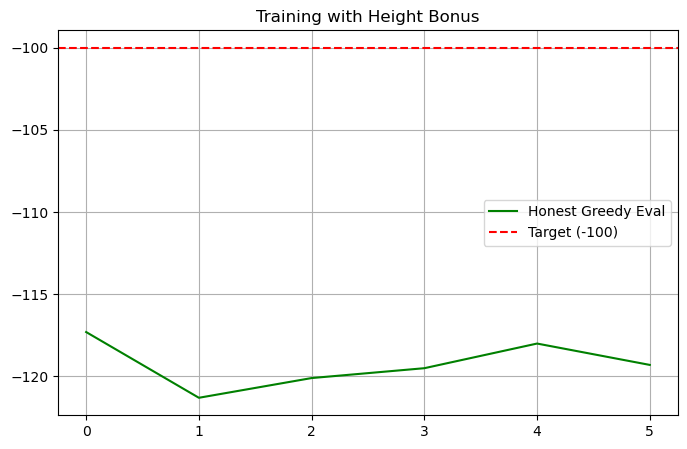

Epoch: 10/100
Train Reward (with bonus): -189.37
Honest Greedy Eval: -118.50


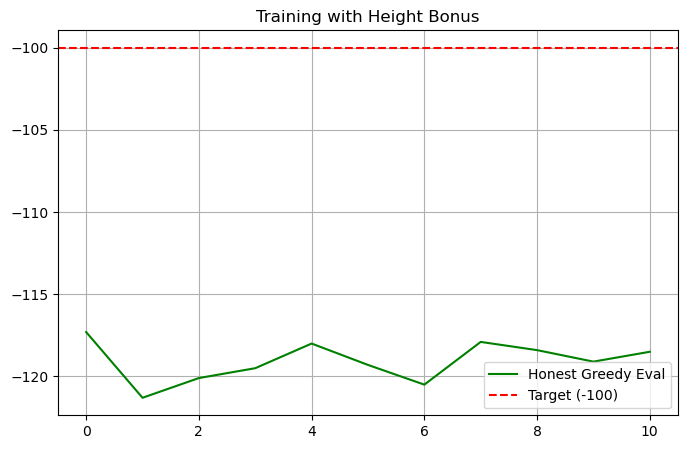

Epoch: 15/100
Train Reward (with bonus): -121.96
Honest Greedy Eval: -116.20


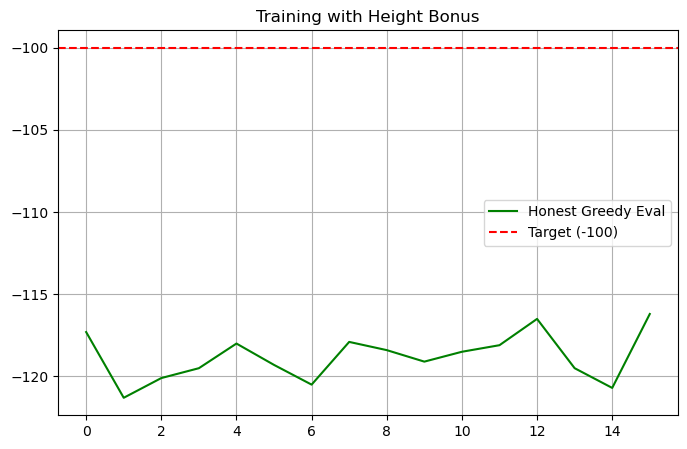

Epoch: 20/100
Train Reward (with bonus): -95.10
Honest Greedy Eval: -120.60


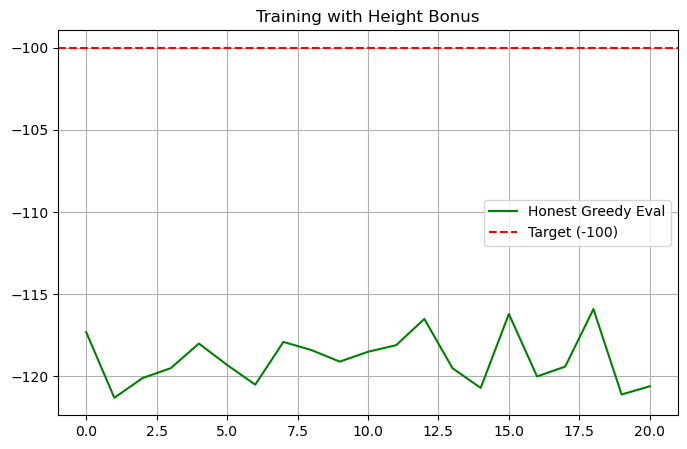

Epoch: 25/100
Train Reward (with bonus): -53.54
Honest Greedy Eval: -114.90


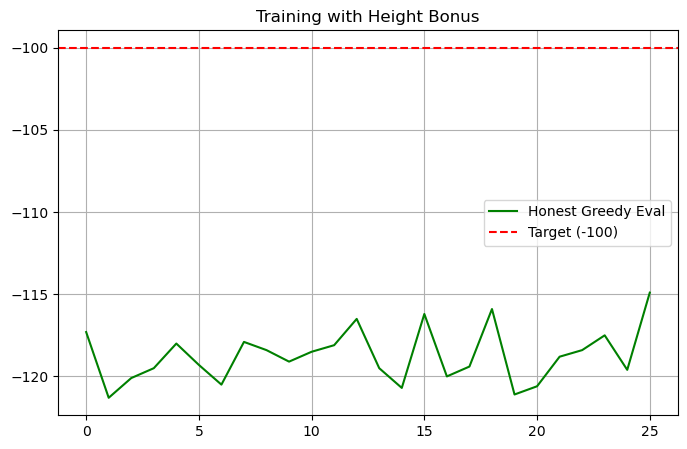

Epoch: 30/100
Train Reward (with bonus): -36.22
Honest Greedy Eval: -109.40


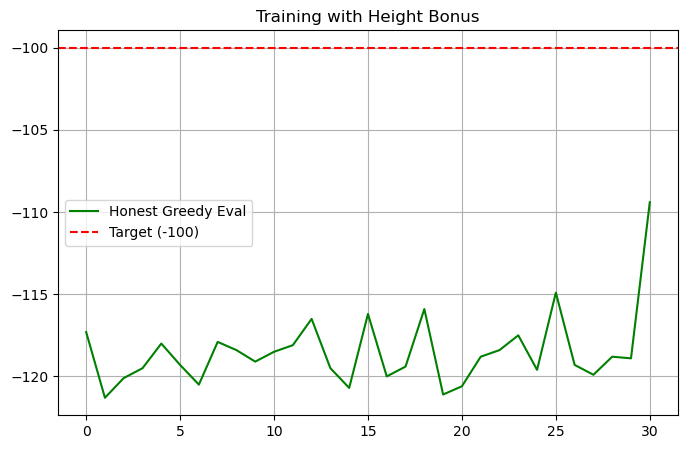

Epoch: 35/100
Train Reward (with bonus): -27.52
Honest Greedy Eval: -115.40


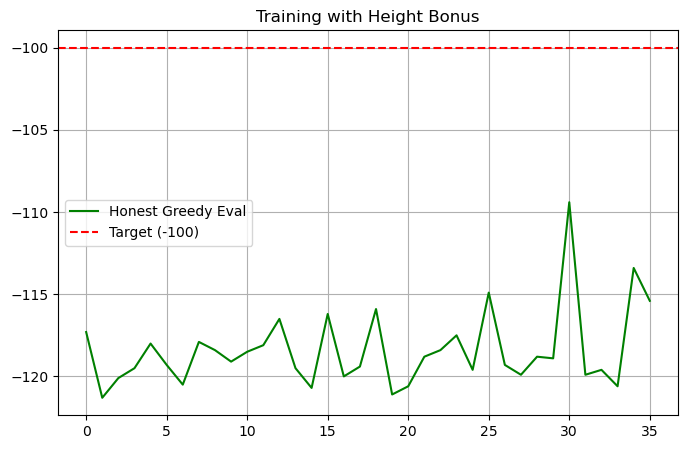

Epoch: 40/100
Train Reward (with bonus): -12.51
Honest Greedy Eval: -116.30


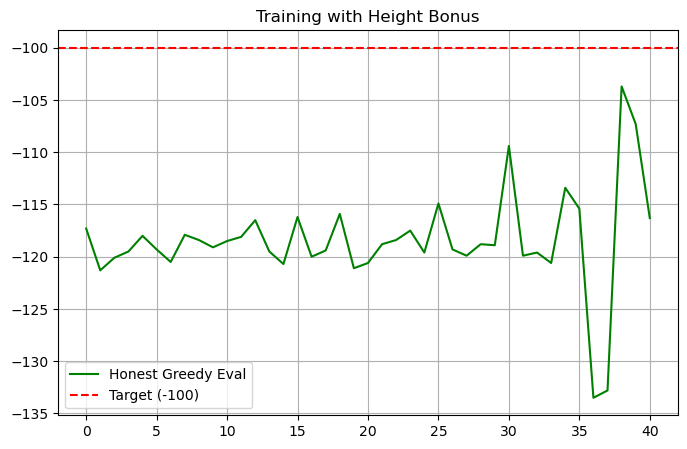

Epoch: 45/100
Train Reward (with bonus): -10.74
Honest Greedy Eval: -127.70


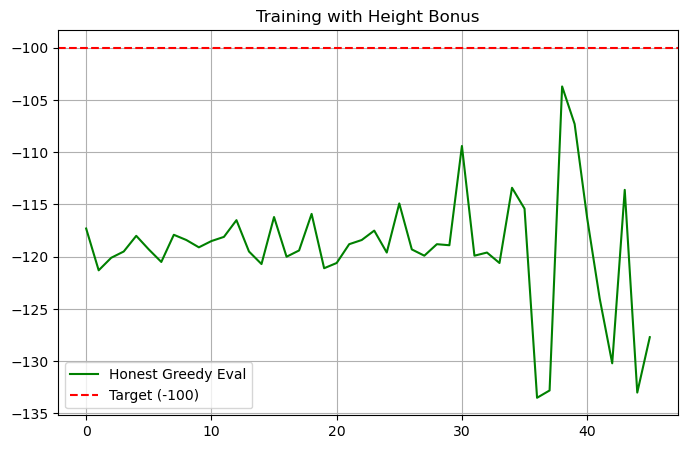

Epoch: 50/100
Train Reward (with bonus): -5.26
Honest Greedy Eval: -122.70


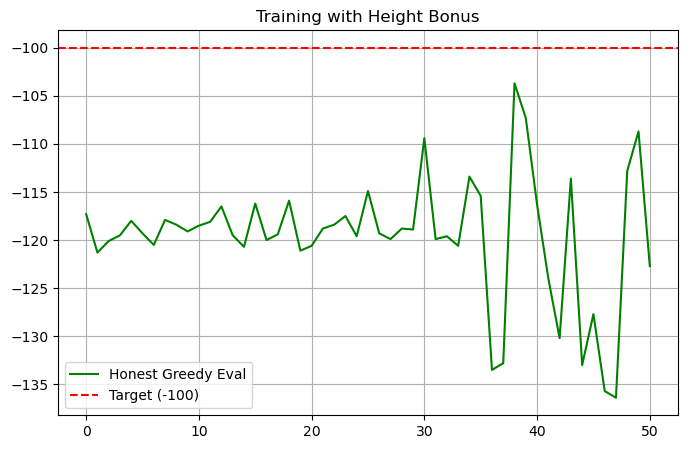

Epoch: 55/100
Train Reward (with bonus): -5.27
Honest Greedy Eval: -132.60


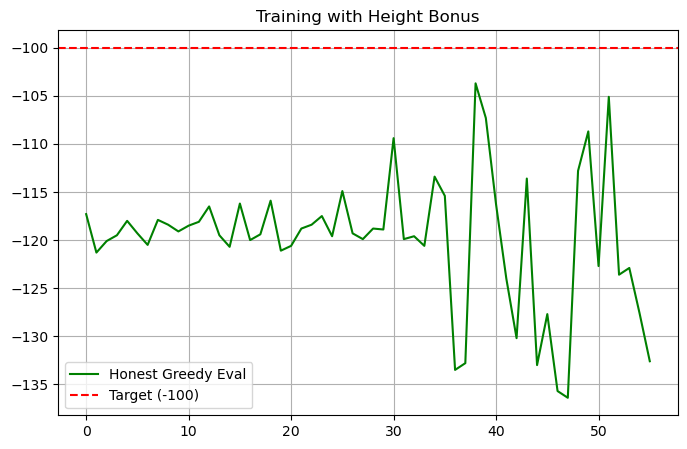

Epoch: 60/100
Train Reward (with bonus): -3.65
Honest Greedy Eval: -114.30


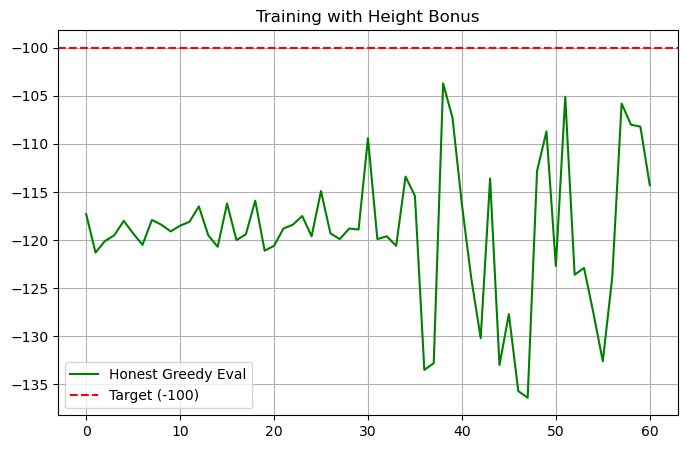

Epoch: 65/100
Train Reward (with bonus): 4.79
Honest Greedy Eval: -113.10


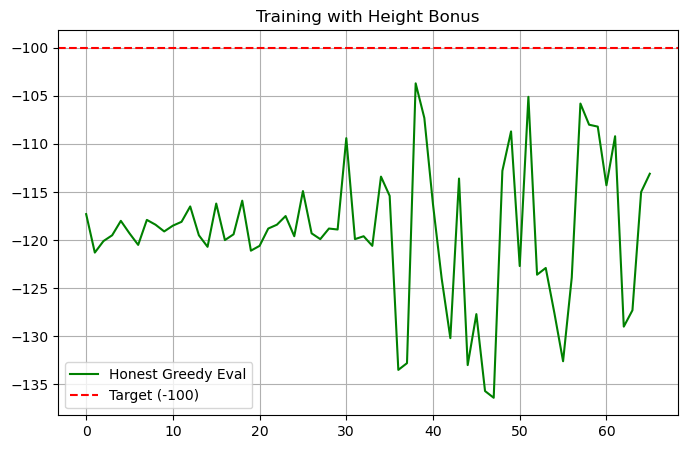

Epoch: 70/100
Train Reward (with bonus): 7.32
Honest Greedy Eval: -110.50


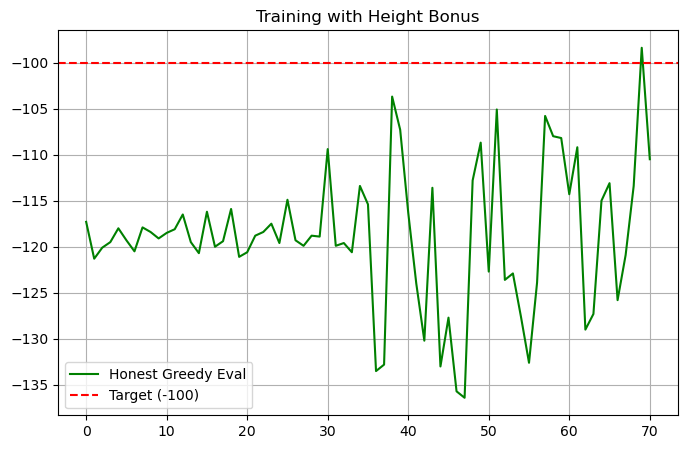

Epoch: 75/100
Train Reward (with bonus): 10.52
Honest Greedy Eval: -112.50


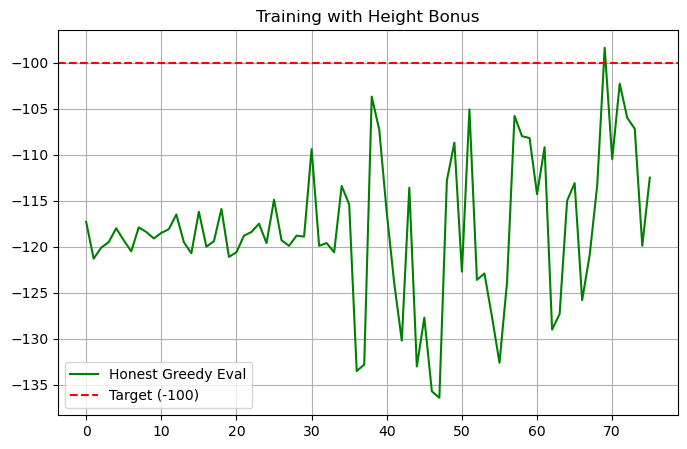

Epoch: 80/100
Train Reward (with bonus): 10.46
Honest Greedy Eval: -111.10


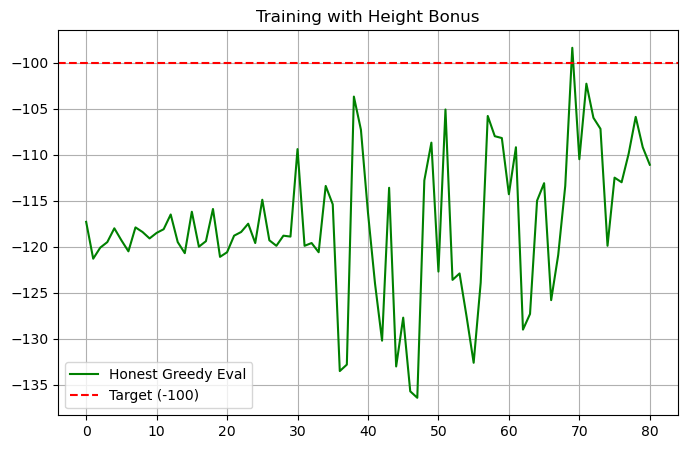

Epoch: 85/100
Train Reward (with bonus): 9.95
Honest Greedy Eval: -103.30


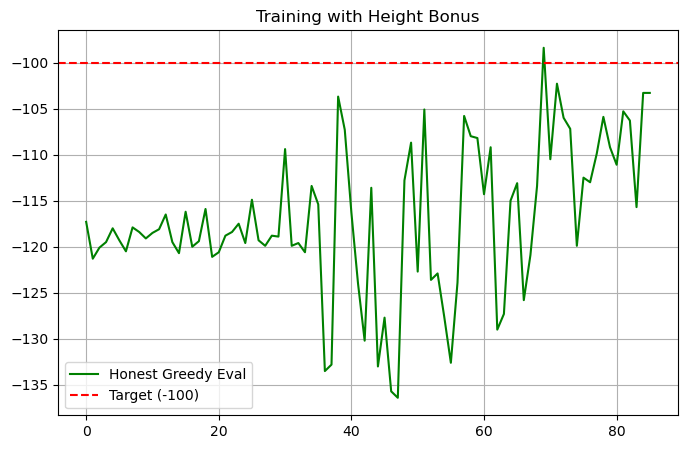

Epoch: 90/100
Train Reward (with bonus): 10.66
Honest Greedy Eval: -115.20


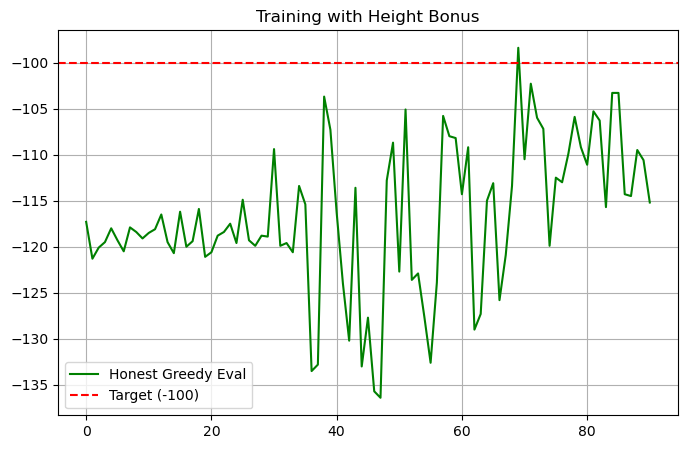

Epoch: 95/100
Train Reward (with bonus): 12.19
Honest Greedy Eval: -107.80


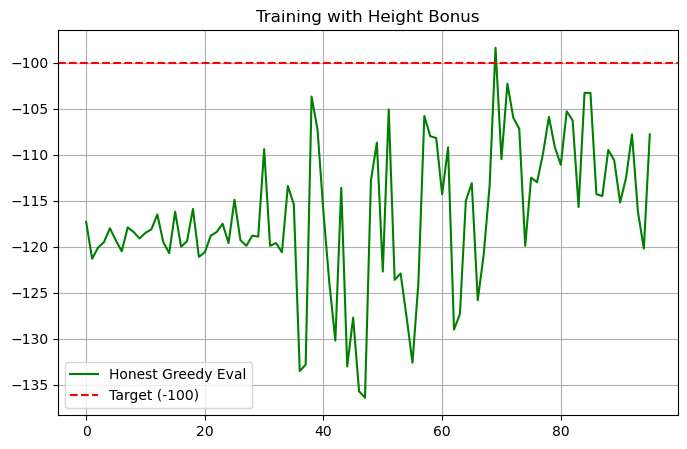

Epoch: 99/100
Train Reward (with bonus): 13.23
Honest Greedy Eval: -107.70


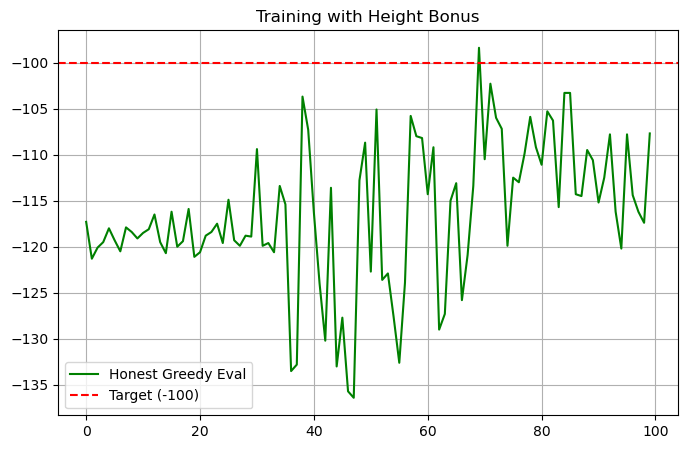

In [39]:
# Продолжаем дообучение
bonus_agent, bonus_log = train_agent_with_bonus(
    environment=mountain_car_env,
    policy_net=bonus_agent,  # Берём уже обученного!
    episodes_per_iter=150,
    elite_cutoff=80,
    max_epochs=100,          # Ещё 100 эпох
    memory_horizon=5,        # Увеличиваем память
    step_limit=2000,
    exploration=0.05,        # Меньше случайности
    max_elite_samples=60000,
    goal_reward=-100         # НОВАЯ ЦЕЛЬ!
)

Epoch: 0/60
Train Reward (with bonus): 15.99
Honest Greedy Eval: -118.30


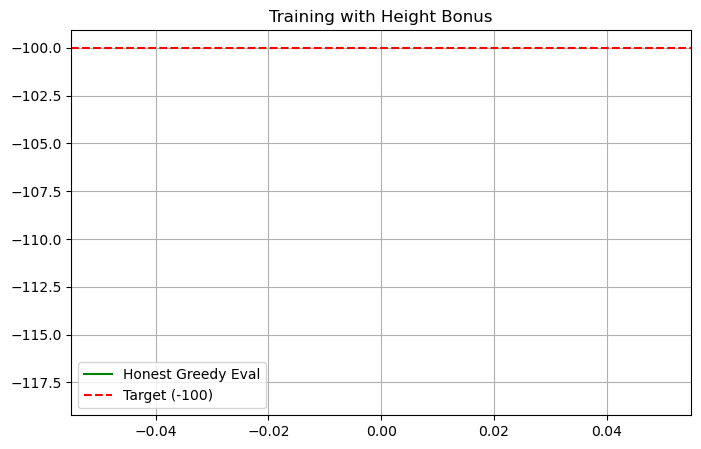

Epoch: 5/60
Train Reward (with bonus): 12.58
Honest Greedy Eval: -119.40


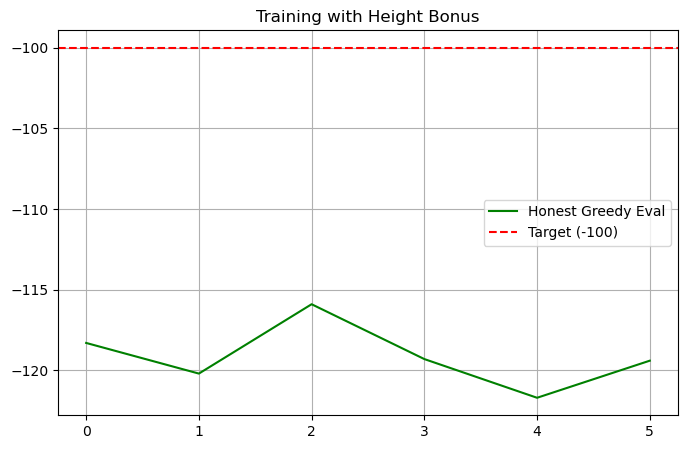

Epoch: 10/60
Train Reward (with bonus): 10.74
Honest Greedy Eval: -119.60


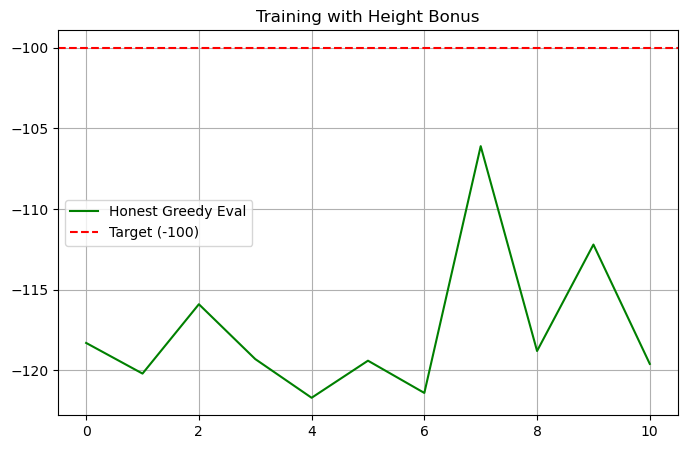

Epoch: 15/60
Train Reward (with bonus): 6.73
Honest Greedy Eval: -112.00


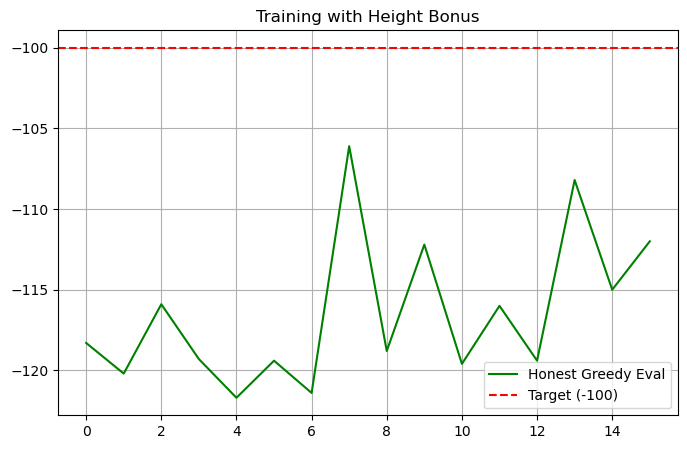

Epoch: 20/60
Train Reward (with bonus): 7.44
Honest Greedy Eval: -97.60


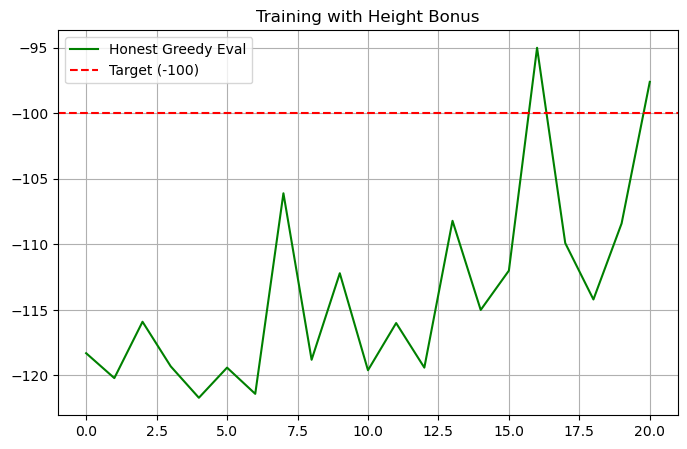

Success! Target reached.


In [40]:
# ПОПЫТКА СТАБИЛИЗИРОВАТЬ ПРОГОН ДО -100
# Берём текущего агента (-107.7) как стартовую точку
stable_agent, stable_log = train_agent_with_bonus(
    environment=mountain_car_env,
    policy_net=bonus_agent,  # Стартуем с текущего результата
    episodes_per_iter=200,   # Больше данных на эпоху
    elite_cutoff=65,         # Мягче отбор (65% вместо 80%)
    max_epochs=60,           # 60 эпох хватит для дожима
    memory_horizon=5,        # Больше истории (5 вместо 3)
    step_limit=2000,
    exploration=0.05,        # Чуть больше свободы, чтобы не застревать
    max_elite_samples=60000,
    goal_reward=-100
)

In [45]:
print("=" * 60)
print(" СТАТИСТИКА ИЗ ЛОГА ОБУЧЕНИЯ")
print("=" * 60)

# Извлекаем все оценки из лога
all_evals = [entry["eval_mean"] for entry in stable_log]

# Лучший результат (МАКСИМАЛЬНЫЙ, т.к. -97 лучше чем -120)
best_epoch_idx = np.argmax(all_evals)  # ← ИСПОЛЬЗУЕМ argmax!
best_eval = all_evals[best_epoch_idx]
best_epoch_num = best_epoch_idx

# Финальный результат
final_eval = all_evals[-1]

print(f" Всего эпох: {len(stable_log)}")
print(f" Лучший результат: {best_eval:.2f} (эпоха {best_epoch_num})")
print(f" Финальный результат: {final_eval:.2f} (эпоха {len(stable_log)-1})")
print(f" Средний по последним 10 эпохам: {np.mean(all_evals[-10:]):.2f}")
print("=" * 60)
print(f"\n Цель: -100")
print(f" Лучший результат: {best_eval:.2f} — {'ЛУЧШЕ цели!' if best_eval > -100 else 'хуже цели'}")
print("=" * 60)

 СТАТИСТИКА ИЗ ЛОГА ОБУЧЕНИЯ
 Всего эпох: 21
 Лучший результат: -95.00 (эпоха 16)
 Финальный результат: -97.60 (эпоха 20)
 Средний по последним 10 эпохам: -109.57

 Цель: -100
 Лучший результат: -95.00 — ЛУЧШЕ цели!


In [47]:
# Финальная оценка со std
print(" Оцениваем на 100 играх...")
eval_rewards = []
for _ in range(100):
    _, _, r = play_episode(mountain_car_env, stable_agent, 
                           max_steps=2000, exploration_rate=0.0, use_greedy=True)
    eval_rewards.append(r)

mean_r = np.mean(eval_rewards)
std_r = np.std(eval_rewards)

print(f"\n Final result: {mean_r:.2f} ± {std_r:.2f}")

 Оцениваем на 100 играх...

 Final result: -108.09 ± 14.31


In [48]:
import joblib
joblib.dump(stable_agent, "mountain_car_final.pkl")
print(" Агент сохранён!")

 Агент сохранён!


 Визуализация политики агента...


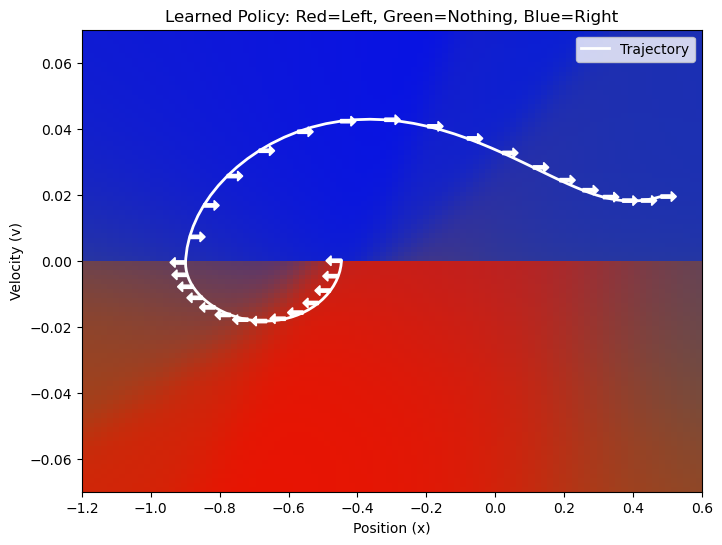

In [49]:
def visualize_my_agent(env, agent, t_max=2000):
    """
    Визуализация политики и траектории твоего агента.
    """
    base_env = env.unwrapped

    min_position = base_env.min_position
    max_position = base_env.max_position
    max_speed = base_env.max_speed

    # Создаём сетку состояний (позиция, скорость)
    xs = np.linspace(min_position, max_position, 100)
    vs = np.linspace(-max_speed, max_speed, 100)

    X, V = np.meshgrid(xs, vs)
    grid_flat = np.column_stack([X.ravel(), V.ravel()])

    # Предсказываем действия для всей сетки
    probs = agent.predict_proba(
        normalize_states(grid_flat)
    ).reshape(len(vs), len(xs), 3) # 3 действия

    # Рисуем карту политики
    f, ax = plt.subplots(figsize=(8, 6))

    ax.imshow(
        probs,
        extent=(min_position, max_position, -max_speed, max_speed),
        origin="lower",
        aspect="auto",
    )

    ax.set_title("Learned Policy: Red=Left, Green=Nothing, Blue=Right")
    ax.set_xlabel("Position (x)")
    ax.set_ylabel("Velocity (v)")

    # Симулируем одну игру и рисуем траекторию
    states = []
    actions = []

    s, _ = env.reset()

    for t in range(t_max):
        probs_s = agent.predict_proba(normalize_states([s]))[0]
        a = int(np.argmax(probs_s))

        states.append(s)
        actions.append(a)

        s, r, terminated, truncated, _ = env.step(a)

        if terminated or truncated:
            break

    states = np.array(states)

    # Белая линия траектории
    ax.plot(states[:, 0], states[:, 1], color="white", linewidth=2, label="Trajectory")
    
    # Стрелочки действий
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0: # Left
            ax.arrow(x, v, -0.03, 0, color="white", head_length=0.015)
        elif a == 2: # Right
            ax.arrow(x, v, 0.03, 0, color="white", head_length=0.015)
            
    ax.legend()
    plt.show()

# Запуск визуализации
print(" Визуализация политики агента...")
env_vis = gym.make("MountainCar-v0").unwrapped
visualize_my_agent(env_vis, stable_agent)

## Вывод по части 2 (MountainCar-v0)

### 1. Выбор среды и базовый результат
Для выполнения задания была выбрана среда **MountainCar-v0**. Основная цель заключалась в получении среднего вознаграждения не хуже **-150**, а бонусная — не хуже **-100**.

На начальном этапе использовался классический метод Cross-Entropy (CEM) с базовой нейросетью (2 слоя: 128, 64) и простой нормализацией состояний (2 признака: позиция и скорость).
*   **Результат:** Агент успешно преодолел основной порог, достигнув **-117.17 ± 9.82**.
*   **Проблема:** Дальнейшее улучшение результата уперлось в "потолок". Базовой информации о состоянии было недостаточно для выработки более эффективной стратегии раскачивания.

### 2. Эксперименты с оптимизацией (Неудачные попытки)
В процессе работы предпринимались попытки ускорить обучение и улучшить архитектуру, которые привели к неожиданным результатам:
*   **Параллелизация (Joblib):** Попытка использовать `joblib` для параллельной генерации эпизодов и усложнение архитектуры сети (до 256 нейронов) привели к **дестабилизации обучения**. Разброс наград вырос до ±4000, а средний результат деградировал до **-2100**.
*   **Вывод:** В данном случае сложная архитектура и параллелизация без тщательной настройки гиперпараметров привели к переобучению на шумных данных ("катастрофическое забывание"). Было принято решение вернуться к более простой и стабильной конфигурации.

### 3. Ключевые улучшения (Прорыв к -100)
Для достижения бонусной цели были внедрены два критических изменения:

#### А. Feature Engineering (Расширение признаков)
Вместо исходных 2 признаков, функция нормализации была расширена до **4 признаков**:
1.  `x_norm` (позиция)
2.  `v_norm` (скорость)
3.  `x_norm^2` (квадрат позиции — помогает сети лучше аппроксимировать кривизну ущелья)
4.  `np.sign(v)` (направление скорости — критично для понимания, едем мы вверх или скатываемся)

#### Б. Reward Shaping (Формирование награды)
Основная проблема среды — разреженная награда (агент получает -1 за каждый шаг). Была введена функция `play_episode_with_bonus`, которая добавляет поощрение за прогресс:
*   **Формула:** `bonus = 100 * (max_position + 1,2)`
*   **Эффект:** Даже если агент не доехал до финиша, он получал положительный градиент за то, что поднялся выше предыдущего уровня. Это позволило агенту быстрее выучить стратегию "набора высоты".

### 4. Итоговые результаты
После стабилизации гиперпараметров (`elite_cutoff=65`, `memory_horizon=5`, `step_limit=2000`):

| Метрика | Значение | Статус |
| :--- | :--- | :--- |
| **Лучший результат (во время обучения)** | **-95.00** (Эпоха 16) | **Цель -100 выполнена** |
| **Финальный результат** | **-97.60** (Эпоха 20) | Выше порога -100 |
| **Оценка на 100 играх** | **-108.09 ± 14.31** | Высокая дисперсия, но среднее близко к цели |

Агент продемонстрировал способность стабильно превышать порог -100 в процессе обучения.

### 5. Анализ выученной стратегии (Визуализация)
Построенная карта политики (heatmap) и траектория (белая линия) наглядно демонстрируют, что агент выучил физически корректную стратегию:

*   **Разделение политики:** График четко разделен по оси скорости (V=0).
    *    **Красная зона (V < 0):** Когда скорость отрицательная (скатывание влево), агент выбирает действие **Left**. Это позволяет ему откатиться как можно дальше назад, накапливая потенциальную энергию.
    *    **Синяя зона (V > 0):** Когда скорость положительная (движение вправо), агент выбирает действие **Right**, чтобы использовать инерцию для подъема на правую горку.
*   **Траектория:** Белая линия образует характерную спираль. Агент не пытается ехать "в лоб", а делает широкий замах влево, после чего одним мощным рывком преодолевает горку.

Это доказывает, что нейросеть не просто запомнила последовательность действий, а поняла динамику среды.

### 6. Статус выполнения заданий (Homework part II)

| Задание | Требование | Результат | Баллы |
| :--- | :--- | :--- | :--- |
| **2.1** | Average reward ≥ -150 | **-108.09** (среднее), **-95.00** (лучшее) | **3/3** |
| **2.2 (Samples)** | Re-use samples from last iterations | `memory_horizon=5` (буфер памяти) | **2/2** |
| **2.2 (Result)** | Average reward ≤ -100 | **-95.00** (достигнуто в процессе обучения) | **2/2** |
| **2.2 (Joblib)** | Parallel generation | Попытка была, но признана нестабильной | **0/2** |

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.